In [2]:
import pandas as pd

In [3]:
data=pd.read_csv('../data/raw/bank.csv',sep=';')
#sep ; because data is seperated by ;

In [4]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


<h2>Basic Data reconnaissance</h2>

In [5]:
data.shape

(4521, 17)

In [6]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


In [8]:
data.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data['y'].value_counts(normalize=True)*100

y
no     88.476001
yes    11.523999
Name: proportion, dtype: float64

<h2>Feature Understanding</h2>

In [11]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [12]:
numerical_columns=['age','balance','day','duration','campaign','pdays','previous']

In [13]:
categoryical_columns=['job','marital','education','default','housing','loan','contact','month','poutcome','y']

In [14]:
data['campaign'].describe()

count    4521.000000
mean        2.793630
std         3.109807
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        50.000000
Name: campaign, dtype: float64

<p>Campaign is number of contacts performed in this campaign for this client , higher campaign means higher number of calls made to retain client</p>

In [15]:
import matplotlib.pyplot as plt

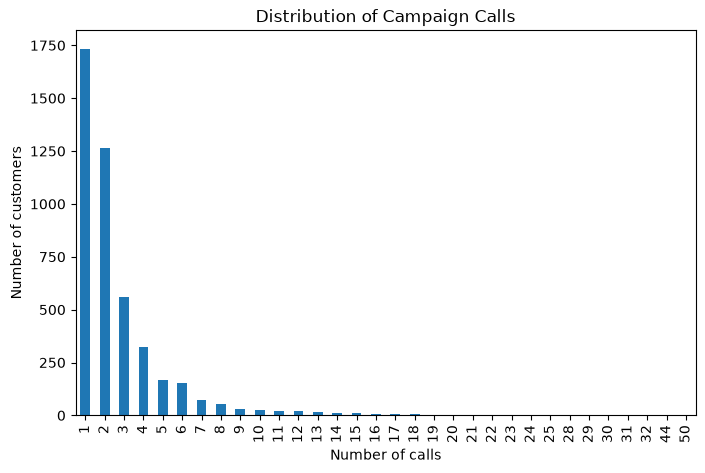

In [16]:
plt.figure(figsize=(8, 5))

data["campaign"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Number of calls")
plt.ylabel("Number of customers")
plt.title("Distribution of Campaign Calls")

plt.show()

In [17]:
data[numerical_columns].describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [18]:
data[numerical_columns].head()

,age,balance,day,duration,campaign,pdays,previous
0,30,1787,19,79,1,-1,0
1,33,4789,11,220,1,339,4
2,35,1350,16,185,1,330,1
3,30,1476,3,199,4,-1,0
4,59,0,5,226,1,-1,0


<h4>Understanding Numerical columns</h4>

In [19]:
data['age'].describe()

count    4521.000000
mean       41.170095
std        10.576211
min        19.000000
25%        33.000000
50%        39.000000
75%        49.000000
max        87.000000
Name: age, dtype: float64

In [20]:
data['balance'].describe()

count     4521.000000
mean      1422.657819
std       3009.638142
min      -3313.000000
25%         69.000000
50%        444.000000
75%       1480.000000
max      71188.000000
Name: balance, dtype: float64

In [21]:
data[data['balance']<0]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no
18,25,blue-collar,single,primary,no,-221,yes,no,unknown,23,may,250,1,-1,0,unknown,no
48,32,entrepreneur,single,primary,yes,-849,yes,yes,cellular,4,feb,204,1,-1,0,unknown,no
60,41,blue-collar,married,primary,no,-516,no,yes,telephone,8,jul,554,3,-1,0,unknown,no
92,27,services,single,secondary,no,-195,yes,no,cellular,18,may,391,1,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4474,44,blue-collar,married,primary,no,-237,yes,no,telephone,10,jul,73,1,-1,0,unknown,no
4502,42,services,married,secondary,no,-91,yes,yes,cellular,5,feb,43,1,-1,0,unknown,no
4506,42,unemployed,divorced,tertiary,no,-166,no,no,cellular,29,aug,85,4,-1,0,unknown,no
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no


In [22]:
data['day'].describe()

count    4521.000000
mean       15.915284
std         8.247667
min         1.000000
25%         9.000000
50%        16.000000
75%        21.000000
max        31.000000
Name: day, dtype: float64

In [23]:
data['duration'].describe()

count    4521.000000
mean      263.961292
std       259.856633
min         4.000000
25%       104.000000
50%       185.000000
75%       329.000000
max      3025.000000
Name: duration, dtype: float64

In [24]:
data['pdays'].describe()

count    4521.000000
mean       39.766645
std       100.121124
min        -1.000000
25%        -1.000000
50%        -1.000000
75%        -1.000000
max       871.000000
Name: pdays, dtype: float64

In [25]:
data[(data['pdays']<=0) & (data['y']=='yes')]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
13,20,student,single,secondary,no,502,no,no,cellular,30,apr,261,1,-1,0,unknown,yes
30,68,retired,divorced,secondary,no,4189,no,no,telephone,14,jul,897,2,-1,0,unknown,yes
33,32,management,single,tertiary,no,2536,yes,no,cellular,26,aug,958,6,-1,0,unknown,yes
34,49,technician,married,tertiary,no,1235,no,no,cellular,13,aug,354,3,-1,0,unknown,yes
36,78,retired,divorced,primary,no,229,no,no,telephone,22,oct,97,1,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4484,38,management,married,tertiary,no,3436,no,no,cellular,21,nov,663,4,-1,0,unknown,yes
4494,26,technician,single,secondary,no,668,yes,no,unknown,28,may,576,3,-1,0,unknown,yes
4503,60,self-employed,married,primary,no,362,no,yes,cellular,29,jul,816,6,-1,0,unknown,yes
4505,32,admin.,single,secondary,no,620,yes,no,unknown,26,may,1234,3,-1,0,unknown,yes


In [26]:
uncontacted = data[data['pdays'] <= 0]

uncontacted.groupby('poutcome')['y'].value_counts()

poutcome  y  
unknown   no     3368
          yes     337
Name: count, dtype: int64

In [27]:
data['previous'].describe()

count    4521.000000
mean        0.542579
std         1.693562
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        25.000000
Name: previous, dtype: float64

<h4>Understanding Categorical columns</h4>

In [28]:
data[categoryical_columns].head()

,job,marital,education,default,housing,loan,contact,month,poutcome,y
0,unemployed,married,primary,no,no,no,cellular,oct,unknown,no
1,services,married,secondary,no,yes,yes,cellular,may,failure,no
2,management,single,tertiary,no,yes,no,cellular,apr,failure,no
3,management,married,tertiary,no,yes,yes,unknown,jun,unknown,no
4,blue-collar,married,secondary,no,yes,no,unknown,may,unknown,no


In [29]:
data[categoryical_columns].nunique()


job          12
marital       3
education     4
default       2
housing       2
loan          2
contact       3
month        12
poutcome      4
y             2
dtype: int64

In [30]:
data['job'].unique()

<StringArray>
[   'unemployed',      'services',    'management',   'blue-collar',
 'self-employed',    'technician',  'entrepreneur',        'admin.',
       'student',     'housemaid',       'retired',       'unknown']
Length: 12, dtype: str

In [31]:
for cols in categoryical_columns:
    print(f'{cols} {data[cols].unique()}')

job <StringArray>
[   'unemployed',      'services',    'management',   'blue-collar',
 'self-employed',    'technician',  'entrepreneur',        'admin.',
       'student',     'housemaid',       'retired',       'unknown']
Length: 12, dtype: str
marital <StringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str
education <StringArray>
['primary', 'secondary', 'tertiary', 'unknown']
Length: 4, dtype: str
default <StringArray>
['no', 'yes']
Length: 2, dtype: str
housing <StringArray>
['no', 'yes']
Length: 2, dtype: str
loan <StringArray>
['no', 'yes']
Length: 2, dtype: str
contact <StringArray>
['cellular', 'unknown', 'telephone']
Length: 3, dtype: str
month <StringArray>
['oct', 'may', 'apr', 'jun', 'feb', 'aug', 'jan', 'jul', 'nov', 'sep', 'mar',
 'dec']
Length: 12, dtype: str
poutcome <StringArray>
['unknown', 'failure', 'other', 'success']
Length: 4, dtype: str
y <StringArray>
['no', 'yes']
Length: 2, dtype: str


<h4>Investigating Values </h4>

In [32]:
# these columns have unknown values 
for col in categoryical_columns:
    if 'unknown' in data[col].unique():
        print(col)

job
education
contact
poutcome


In [33]:
unknown_job=data[data['job']=='unknown']

In [34]:
unknown_job['y'].value_counts()

y
no     31
yes     7
Name: count, dtype: int64

In [35]:
unknown_education=data[data['education']=='unknown']

In [36]:
unknown_education['y'].value_counts()

y
no     168
yes     19
Name: count, dtype: int64

In [37]:
data.groupby('contact')['y'].value_counts(normalize=True)*100

contact    y  
cellular   no     85.635359
           yes    14.364641
telephone  no     85.382060
           yes    14.617940
unknown    no     95.392749
           yes     4.607251
Name: proportion, dtype: float64

In [38]:
data.groupby('poutcome')['y'].value_counts(normalize=True)*100

poutcome  y  
failure   no     87.142857
          yes    12.857143
other     no     80.710660
          yes    19.289340
success   yes    64.341085
          no     35.658915
unknown   no     90.904184
          yes     9.095816
Name: proportion, dtype: float64

In [39]:
data[data['pdays']==-1]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,unknown,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,unknown,14,may,57,2,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4513,49,blue-collar,married,secondary,no,322,no,no,cellular,14,aug,356,2,-1,0,unknown,no
4515,32,services,single,secondary,no,473,yes,no,cellular,7,jul,624,5,-1,0,unknown,no
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no


In [42]:
neg_or_zero_balance=data[data['balance']<=0]

In [46]:
neg_or_zero_balance['y'].value_counts(normalize=True)

y
no     0.917012
yes    0.082988
Name: proportion, dtype: float64

In [47]:
neg_or_zero_balance

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no
18,25,blue-collar,single,primary,no,-221,yes,no,unknown,23,may,250,1,-1,0,unknown,no
20,38,management,divorced,unknown,no,0,yes,no,cellular,18,nov,96,2,-1,0,unknown,no
47,26,blue-collar,married,primary,no,0,yes,no,unknown,21,may,425,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4493,28,technician,single,tertiary,no,0,yes,no,unknown,4,jun,205,6,-1,0,unknown,no
4502,42,services,married,secondary,no,-91,yes,yes,cellular,5,feb,43,1,-1,0,unknown,no
4506,42,unemployed,divorced,tertiary,no,-166,no,no,cellular,29,aug,85,4,-1,0,unknown,no
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no


In [ ]:
#neg or zero balance prob means overdraft

In [48]:
#unknown row per category

In [52]:
for col in categoryical_columns:
   if 'unknown' in data[col].values:
      print(f'{col} : {(data[col]=='unknown').sum()}')

job : 38
education : 187
contact : 1324
poutcome : 3705


In [53]:
poutcome_unknown=data[data['poutcome']=='unknown']

In [55]:
poutcome_unknown['pdays'].value_counts(normalize=True)

pdays
-1    1.0
Name: proportion, dtype: float64

<h3>Relationship EDA 💆‍♀️</h3>

In [61]:
#relationship between different jobs and outcome
data.groupby('job')['y'].value_counts()

job            y  
admin.         no     420
               yes     58
blue-collar    no     877
               yes     69
entrepreneur   no     153
               yes     15
housemaid      no      98
               yes     14
management     no     838
               yes    131
retired        no     176
               yes     54
self-employed  no     163
               yes     20
services       no     379
               yes     38
student        no      65
               yes     19
technician     no     685
               yes     83
unemployed     no     115
               yes     13
unknown        no      31
               yes      7
Name: count, dtype: int64

In [62]:
#relation between contact type and yes
data.groupby('contact')['y'].value_counts()

contact    y  
cellular   no     2480
           yes     416
telephone  no      257
           yes      44
unknown    no     1263
           yes      61
Name: count, dtype: int64